# VAYU - Notebook 1: EDA & Data Cleaning

**Input:** Hugging Face dataset `rachitgoyell/vayu-raw` → `data/raw/aqi_india_38cols_knn_final.csv`

**Outputs:**
- `data/cleaned/00_shared/master_cleaned.csv`
- `data/cleaned/01_classification/clf_train_unscaled.csv` + `clf_test_unscaled.csv`
- `models/city_encoder.pkl`, `models/scaler.pkl`/

**Run this first.** All other notebooks depend on its outputs.

---

### Steps
1. Load raw data, column audit
2. EDA — nulls, sentinels, distributions, correlations
3. Cleaning — sentinel replacement, range validation, ffill, dedup, label remap
4. Encoding — ordinal AQI category, label-encode city
5. Feature selection — correlation + RF importance
6. Regression dataset prep (AQI, lags, chronological split)
7. Classification dataset prep (stratified split, scaling)
8. Summary of all output files


## Objective
This notebook is the foundation of the entire VAYU project. It takes raw AQI data and transforms it into clean, structured, and model-ready datasets for both regression and classification tasks.

All downstream notebooks — forecaster, classifier, and SHAP explainer — depend on the outputs generated here. Therefore, correctness and reproducibility in this notebook are critical.

## Input
Hugging Face dataset `rachitgoyell/vayu-raw` → `data/raw/aqi_india_38cols_knn_final.csv`

## Outputs
- data/cleaned/00_shared/master_cleaned.csv  
- data/cleaned/01_classification/clf_train_unscaled.csv / test.csv  
- data/cleaned/01_classification/clf_train_scaled.csv / test.csv  
- models/city_encoder.pkl  
- models/scaler.pkl  

## Key Tasks
1. Perform EDA to understand data issues  
2. Apply strict cleaning pipeline (order matters)  
3. Encode categorical variables  
4. Select important features  
5. Prepare regression and classification datasets  

⚠️ This notebook must be run before all others.

In [42]:
import os, json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# ---------------------------
# ROOT PATH FIX (CRITICAL)
# ---------------------------
ROOT_DIR = Path.cwd().parent  # one level above notebooks/
DATA_DIR = ROOT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
CLEANED_DIR = DATA_DIR / "cleaned"
MODEL_DIR = ROOT_DIR / "models"

# create dirs if not exist
RAW_DIR.mkdir(parents=True, exist_ok=True)
CLEANED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------
# CONFIG
# ---------------------------
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')
pd.set_option('display.max_columns', 40)

# ---------------------------
# HuggingFace dataset download
# ---------------------------
try:
    from huggingface_hub import snapshot_download
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'huggingface_hub'])
    from huggingface_hub import snapshot_download

HF_REPO  = 'rachitgoyell/vayu-raw'
RAW_PATH = RAW_DIR / 'aqi_india_38cols_knn_final.csv'

if not RAW_PATH.exists():
    print(f'Downloading raw data from Hugging Face: {HF_REPO}')
    snapshot_download(
        repo_id=HF_REPO,
        repo_type='dataset',
        local_dir=str(RAW_DIR),
        local_dir_use_symlinks=False,
    )
else:
    print(f'Raw data already available at {RAW_PATH}')

# ---------------------------
# Cleaned data paths
# ---------------------------
SHARED_DIR = CLEANED_DIR / "00_shared"
CLF_DIR    = CLEANED_DIR / "01_classification"
SHAP_DIR = CLEANED_DIR / "02_shap"

SHARED_DIR.mkdir(parents=True, exist_ok=True)
CLF_DIR.mkdir(parents=True, exist_ok=True)
SHAP_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------
# AQI metadata
# ---------------------------
CAT_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']

CAT_COLORS = {
    'Good':'#00E400',
    'Satisfactory':'#92D050',
    'Moderate':'#FFFF00',
    'Poor':'#FF7E00',
    'Very Poor':'#FF0000',
    'Severe':'#99004C',
}

CAT_TO_INT = {c: i for i, c in enumerate(CAT_ORDER)}
INT_TO_CAT = {i: c for i, c in enumerate(CAT_ORDER)}

# ---------------------------
# Label mapping
# ---------------------------
CAT_MAP = {
    'Good': 'Good',
    'Satisfactory': 'Satisfactory',
    'Moderate': 'Moderate',
    'Unhealthy for Sensitive Groups': 'Poor',
    'Unhealthy for Sensitive': 'Poor',
    'Unhealthy': 'Very Poor',
    'Very Unhealthy': 'Severe',
    'Hazardous': 'Severe',
    'Poor': 'Poor',
    'Very Poor': 'Very Poor',
    'Severe': 'Severe',
}

# ---------------------------
# Physical ranges
# ---------------------------
PHYSICAL_RANGES = {
    'pm2_5_ugm3': (0, 1000),
    'pm10_ugm3':  (0, 1500),
    'co_ugm3':    (0, 50000),
    'no2_ugm3':   (0, 1000),
    'so2_ugm3':   (0, 2000),
    'o3_ugm3':    (0, 1000),
}

# ---------------------------
# CPCB AQI breakpoints
# ---------------------------
BREAKPOINTS = {
    'pm2_5': [(0,30,0,50),(31,60,51,100),(61,90,101,200),(91,120,201,300),(121,250,301,400),(251,500,401,500)],
    'pm10':  [(0,50,0,50),(51,100,51,100),(101,250,101,200),(251,350,201,300),(351,430,301,400),(431,600,401,500)],
    'no2':   [(0,40,0,50),(41,80,51,100),(81,180,101,200),(181,280,201,300),(281,400,301,400),(401,1000,401,500)],
    'so2':   [(0,40,0,50),(41,80,51,100),(81,380,101,200),(381,800,201,300),(801,1600,301,400),(1601,2000,401,500)],
    'o3':    [(0,50,0,50),(51,100,51,100),(101,168,101,200),(169,208,201,300),(209,748,301,400),(749,1000,401,500)],
    'co':    [(0,1,0,50),(1.1,2,51,100),(2.1,10,101,200),(10.1,17,201,300),(17.1,34,301,400),(34.1,50,401,500)],
}

# ---------------------------
# Debug prints
# ---------------------------
print("Setup complete.")
print(f"ROOT DIR: {ROOT_DIR}")
print(f"RAW DATA PATH: {RAW_PATH}")
print(f"DATA DIR: {DATA_DIR}")
print(f"MODEL DIR: {MODEL_DIR}")

Raw data already available at d:\vayu\data\raw\aqi_india_38cols_knn_final.csv
Setup complete.
ROOT DIR: d:\vayu
RAW DATA PATH: d:\vayu\data\raw\aqi_india_38cols_knn_final.csv
DATA DIR: d:\vayu\data
MODEL DIR: d:\vayu\models


## Step 1: Load Data and Perform Initial Audit

In this step, we load the raw AQI dataset and perform an initial inspection. This helps us understand the structure, column names, and data types.

We specifically look for:
- Shape of dataset
- Column list
- Data types
- Initial anomalies

This step ensures we are working with the correct dataset before proceeding further.

In [35]:


df = pd.read_csv(RAW_PATH, parse_dates=['datetime'])
print(f'Raw dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range: {df["datetime"].min()} → {df["datetime"].max()}')
print(f'Cities: {df["city"].nunique()}')
print()
print('Columns:')
for i, col in enumerate(df.columns):
    print(f'  {i:2d}. {col:<30} {df[col].dtype}')

# Keep only relevant columns
KEEP_COLS = [
    'city', 'datetime', 'month', 'is_weekend',
    'pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3',
    'aqi_category',
]
df = df[KEEP_COLS].copy()

# Derive hour and day_of_week from datetime
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek

print(f'Working dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Raw dataset: 846,371 rows × 31 columns
Date range: 2022-08-05 00:00:00 → 2025-11-26 23:00:00
Cities: 29

Columns:
   0. city                           object
   1. state                          object
   2. latitude                       float64
   3. longitude                      float64
   4. datetime                       datetime64[ns]
   5. month                          float64
   6. day_name                       object
   7. is_weekend                     object
   8. season                         object
   9. time_of_day                    object
  10. humidity_percent               float64
  11. dew_point_c                    float64
  12. wind_gusts_kmh                 float64
  13. precipitation_mm               float64
  14. is_raining                     object
  15. heavy_rain                     object
  16. pressure_msl_hpa               float64
  17. cloud_cover_percent            float64
  18. pm2_5_ugm3                     float64
  19. pm10_ugm3                 

,city,datetime,month,is_weekend,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3,aqi_category,hour,day_of_week
0,agartala,2022-08-05 00:00:00,8.0,False,14.8,21.5,197.0,21.8,2.7,32.0,Very Unhealthy,0.0,4.0
1,agartala,2022-08-05 01:00:00,8.0,False,15.7,22.8,196.0,18.5,3.0,33.0,Very Unhealthy,1.0,4.0
2,agartala,2022-08-05 02:00:00,8.0,False,16.3,23.5,196.0,15.1,3.3,34.0,Moderate,2.0,4.0
3,agartala,2022-08-05 03:00:00,8.0,False,17.6,25.4,197.0,14.1,3.3,32.0,Moderate,3.0,4.0
4,agartala,2022-08-05 04:00:00,8.0,False,18.2,26.2,199.0,13.9,3.2,30.0,Moderate,4.0,4.0


## Step 2: Exploratory Data Analysis (EDA)

This step identifies major data quality issues before cleaning.

We analyze:
1. Missing values across columns  
2. Sentinel values (999 in CO column)  
3. AQI category distribution  
4. General data consistency  

The dataset intentionally contains:
- Random NaNs (~0.5%)  
- Duplicate rows  
- Sentinel value 999  

Identifying these issues helps us design a proper cleaning pipeline.

NULL COUNTS
  city                  4,236  (0.50%) ← ~0.5% intentional
  datetime              4,236  (0.50%) ← ~0.5% intentional
  month                 4,222  (0.50%) ← ~0.5% intentional
  is_weekend            4,233  (0.50%) ← ~0.5% intentional
  pm2_5_ugm3            4,227  (0.50%) ← ~0.5% intentional
  pm10_ugm3             4,230  (0.50%) ← ~0.5% intentional
  co_ugm3               4,230  (0.50%) ← ~0.5% intentional
  no2_ugm3              4,233  (0.50%) ← ~0.5% intentional
  so2_ugm3              4,235  (0.50%) ← ~0.5% intentional
  o3_ugm3               4,232  (0.50%) ← ~0.5% intentional
  aqi_category          4,228  (0.50%) ← ~0.5% intentional
  hour                  4,236  (0.50%) ← ~0.5% intentional
  day_of_week           4,236  (0.50%) ← ~0.5% intentional
Sentinel value 999 in co_ugm3: 124 rows
  These will be replaced with NaN in cleaning step
PHYSICAL RANGE VIOLATIONS
  pm2_5_ugm3           out of [0, 1000]: 0
  pm10_ugm3            out of [0, 1500]: 0
  co_ugm3         

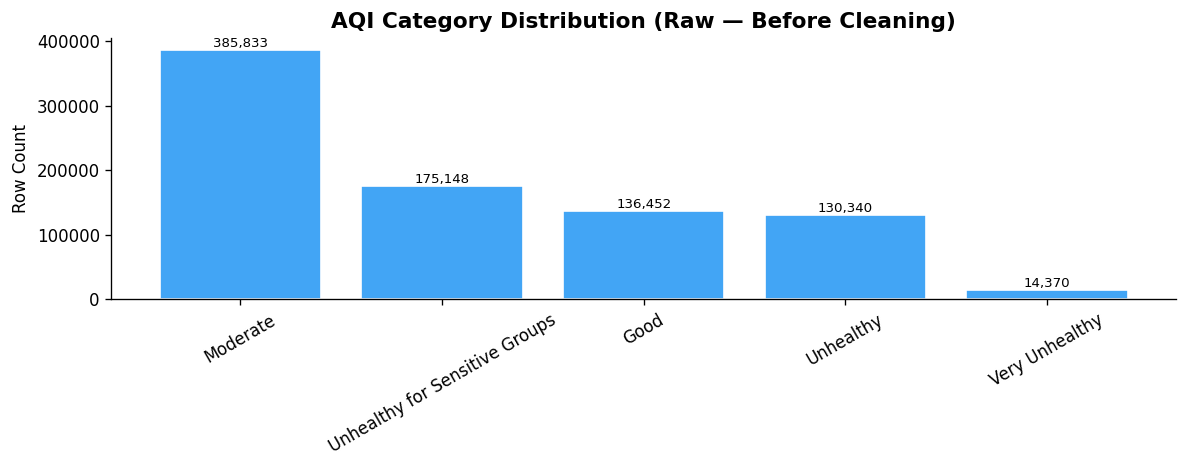

aqi_category
Moderate                          385833
Unhealthy for Sensitive Groups    175148
Good                              136452
Unhealthy                         130340
Very Unhealthy                     14370


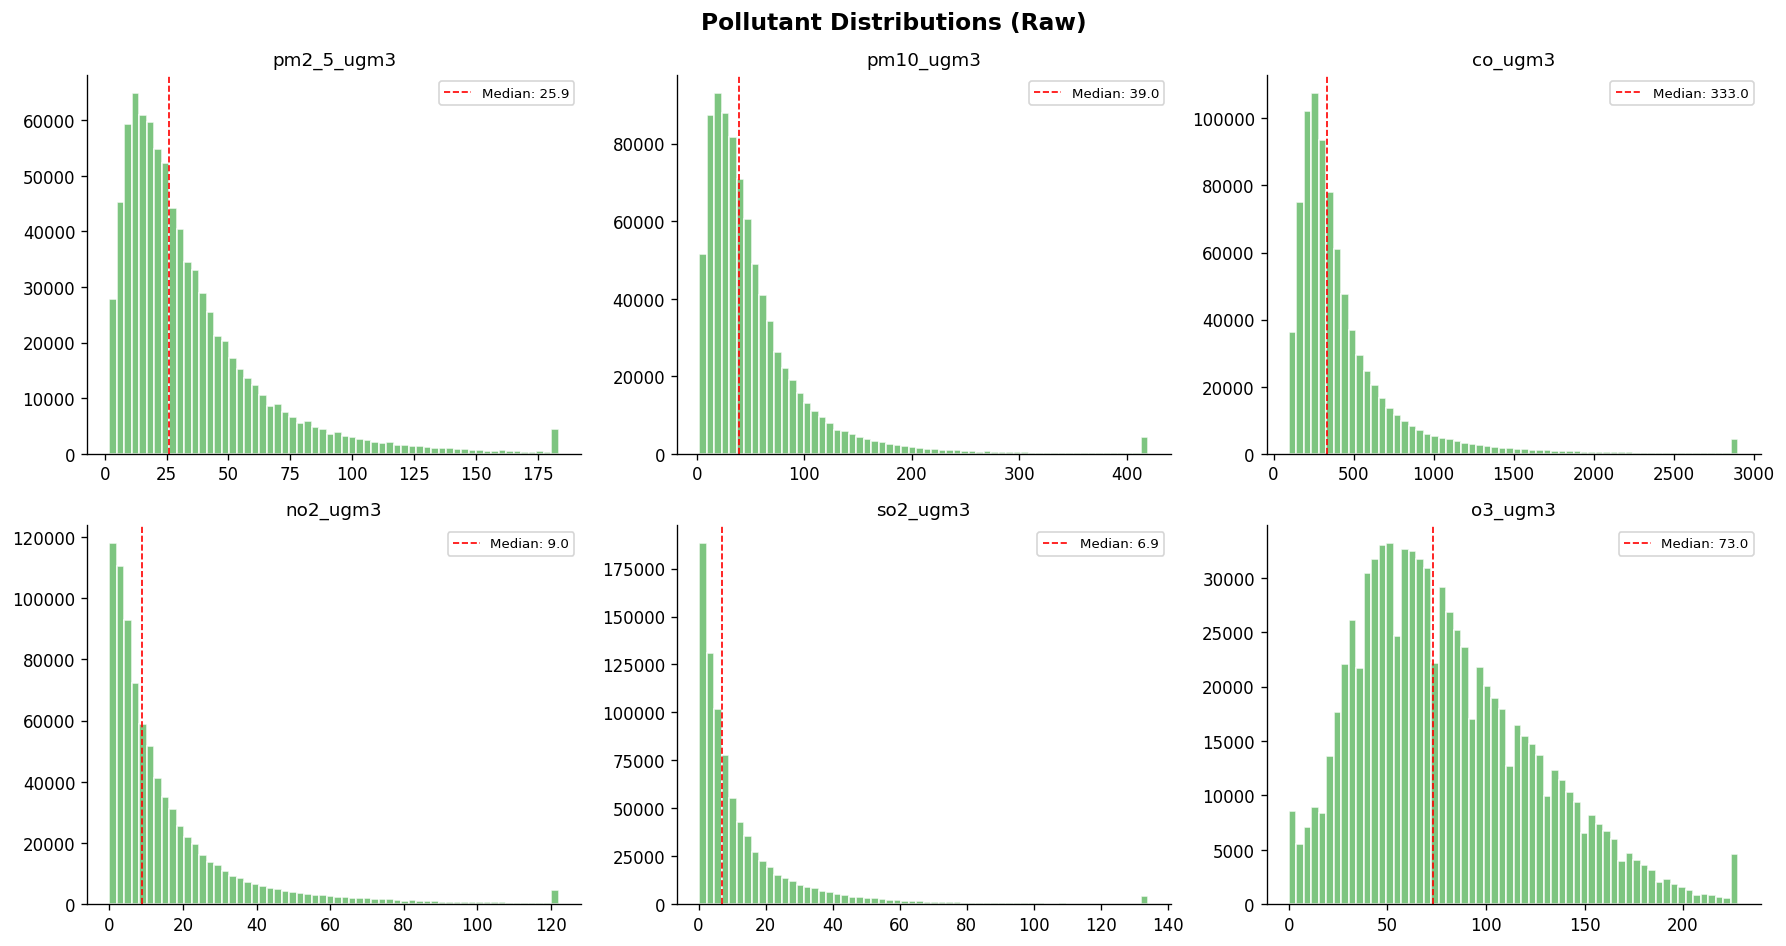

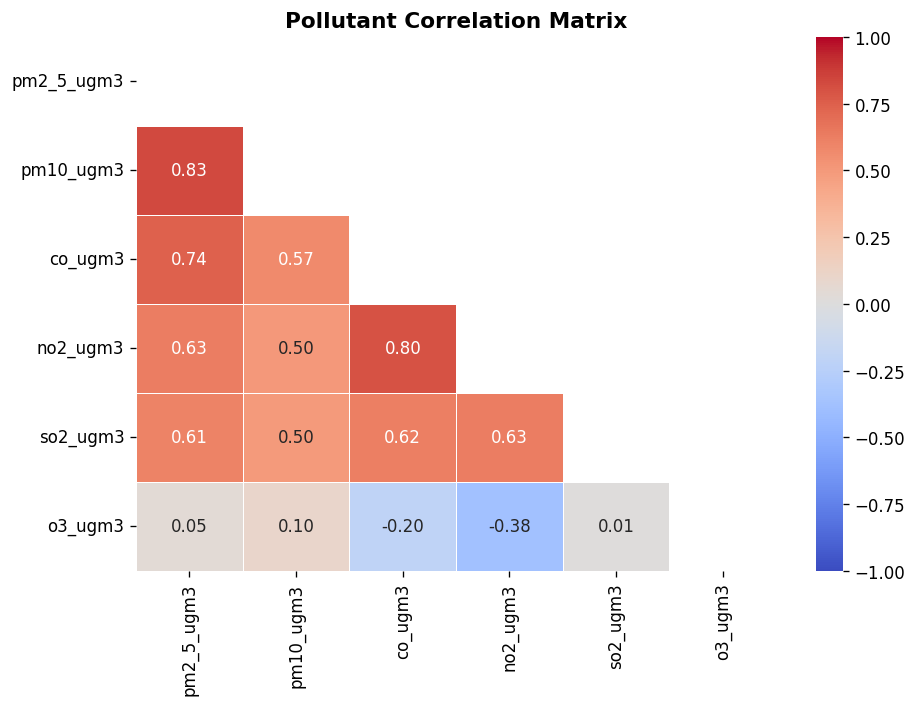

High correlations (> 0.85):
  None found — no features dropped by correlation filter


In [36]:
# 2.1 — Null counts
print('NULL COUNTS')
print('=' * 40)
nulls = df.isnull().sum()
for col, n in nulls.items():
    pct = n / len(df) * 100
    flag = ' ← ~0.5% intentional' if 0.3 < pct < 1.0 else ''
    print(f'  {col:<20} {n:>6,}  ({pct:.2f}%){flag}')


# 2.2 — Sentinel 999 in co_ugm3
sentinel_mask = df['co_ugm3'] == 999
n_sentinel = sentinel_mask.sum()
print(f'Sentinel value 999 in co_ugm3: {n_sentinel:,} rows')
if n_sentinel > 0:
    print(f'  These will be replaced with NaN in cleaning step')


# 2.3 — Physical range violations
print('PHYSICAL RANGE VIOLATIONS')
print('=' * 50)
for col, (lo, hi) in PHYSICAL_RANGES.items():
    violations = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'  {col:<20} out of [{lo}, {hi}]: {violations:,}')


# 2.4 — AQI category distribution (raw)
fig, ax = plt.subplots(figsize=(10, 4))
raw_cats = df['aqi_category'].value_counts()
bars = ax.bar(raw_cats.index, raw_cats.values, color='#42A5F5', edgecolor='white')
for bar, val in zip(bars, raw_cats.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', va='bottom', fontsize=8)
ax.set_title('AQI Category Distribution (Raw — Before Cleaning)', fontsize=13, fontweight='bold')
ax.set_ylabel('Row Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()
print(raw_cats.to_string())


# 2.5 — Pollutant distributions
pollutant_cols = ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), pollutant_cols):
    data = df[col].dropna()
    ax.hist(data, bins=60, color='#66BB6A', edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1, label=f'Median: {data.median():.1f}')
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)
plt.suptitle('Pollutant Distributions (Raw)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 2.6 — Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[pollutant_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Pollutant Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Flag high correlations
print('High correlations (> 0.85):')
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.85:
            print(f'  {corr.index[i]} ↔ {corr.columns[j]}: {corr.iloc[i,j]:.3f}')
if not any(abs(corr.iloc[i,j]) > 0.85 for i in range(len(corr)) for j in range(i+1, len(corr))):
    print('  None found — no features dropped by correlation filter')

## Step 3: Cleaning Pipeline (STRICT ORDER)

Cleaning must be applied in the exact order defined in the project specification:

1. Replace sentinel 999 → NaN  
2. Remove physically invalid values  
3. Forward fill short gaps (limit=3, per city)  
4. Drop rows where all pollutants are missing  
5. Remove duplicate rows  

Order is critical because:
- Forward fill should only apply after cleaning invalid values  
- Dropping rows before filling may remove useful data  
- Deduplication must happen after cleaning  

We also track row counts at each step.

In [37]:
cleaning_log = []
initial_rows = len(df)

# Step 1: Sentinel 999 → NaN
before = len(df)
n_sentinel = (df['co_ugm3'] == 999).sum()
df.loc[df['co_ugm3'] == 999, 'co_ugm3'] = np.nan
cleaning_log.append(('Replace sentinel 999→NaN', before, before, n_sentinel, 'co_ugm3 only'))
print(f'Step 1: Replaced {n_sentinel:,} sentinel values (999) in co_ugm3 with NaN')

# Step 2: Physical range validation
before = len(df)
range_nulled = 0
for col, (lo, hi) in PHYSICAL_RANGES.items():
    mask = (df[col] < lo) | (df[col] > hi)
    n = mask.sum()
    df.loc[mask, col] = np.nan
    range_nulled += n
cleaning_log.append(('Physical range validation', before, before, range_nulled, 'nulled out-of-range'))
print(f'Step 2: Nulled {range_nulled:,} out-of-range readings')

# Step 3: Forward fill (limit=3, per city)
before_nulls = df[pollutant_cols].isnull().sum().sum()
df[pollutant_cols] = df.groupby('city')[pollutant_cols].transform(
    lambda x: x.ffill(limit=3)
)
after_nulls = df[pollutant_cols].isnull().sum().sum()
filled = before_nulls - after_nulls
cleaning_log.append(('Forward fill (limit=3)', len(df), len(df), filled, 'nulls filled'))
print(f'Step 3: Forward-filled {filled:,} null values (limit=3 per city group)')

# Step 4: Drop rows where ALL 6 pollutants are NaN
before = len(df)
all_nan_mask = df[pollutant_cols].isnull().all(axis=1)
df = df[~all_nan_mask].copy()
removed = before - len(df)
cleaning_log.append(('Drop all-NaN pollutant rows', before, len(df), removed, ''))
print(f'Step 4: Dropped {removed:,} rows (all 6 pollutants NaN). Remaining: {len(df):,}')

# Step 5: Deduplicate on (city, datetime)
before = len(df)
df = df.drop_duplicates(subset=['city', 'datetime'], keep='first')
removed = before - len(df)
cleaning_log.append(('Deduplicate (city, datetime)', before, len(df), removed, ''))
print(f'Step 5: Removed {removed:,} duplicate rows. Remaining: {len(df):,}')

# Step 6: Remap labels
before_cats = df['aqi_category'].value_counts()
df['aqi_category'] = df['aqi_category'].map(CAT_MAP)
unmapped = df['aqi_category'].isnull().sum()
if unmapped > 0:
    print(f'  WARNING: {unmapped} rows have unmapped categories — dropping them')
    df = df.dropna(subset=['aqi_category'])
after_cats = df['aqi_category'].value_counts()
cleaning_log.append(('Remap US EPA → CPCB', len(df), len(df), 0, 'label remap'))
print(f'Step 6: Remapped US EPA labels to CPCB. Final rows: {len(df):,}')

print()
print(f'CLEANING SUMMARY: {initial_rows:,} → {len(df):,} rows ({initial_rows - len(df):,} removed)')



# Compute CPCB AQI from sub-indices
def compute_subindex(value, breakpoints):
    if pd.isna(value):
        return np.nan
    for (c_lo, c_hi, i_lo, i_hi) in breakpoints:
        if c_lo <= value <= c_hi:
            return i_lo + (value - c_lo) * (i_hi - i_lo) / (c_hi - c_lo)
    return np.nan

def compute_aqi(row):
    subindices = [
        compute_subindex(row['pm2_5_ugm3'], BREAKPOINTS['pm2_5']),
        compute_subindex(row['pm10_ugm3'],  BREAKPOINTS['pm10']),
        compute_subindex(row['no2_ugm3'],   BREAKPOINTS['no2']),
        compute_subindex(row['so2_ugm3'],   BREAKPOINTS['so2']),
        compute_subindex(row['o3_ugm3'],    BREAKPOINTS['o3']),
        compute_subindex(row['co_ugm3'] / 1000, BREAKPOINTS['co']),  # µg/m³ → mg/m³
    ]
    valid = [s for s in subindices if not np.isnan(s)]
    return max(valid) if valid else np.nan

df['AQI'] = df.apply(compute_aqi, axis=1)
print(f"AQI computed — mean: {df['AQI'].mean():.1f}, nulls: {df['AQI'].isna().sum():,}")



# Cleaning log table
log_df = pd.DataFrame(cleaning_log, columns=['Step', 'Before', 'After', 'Affected', 'Notes'])
print(log_df.to_string(index=False))


# Post-cleaning category distribution
print('\nPost-cleaning AQI category distribution:')
cat_dist = df['aqi_category'].value_counts().reindex(CAT_ORDER).fillna(0).astype(int)
for cat, count in cat_dist.items():
    pct = count / len(df) * 100
    flag = ' ← genuinely absent' if count == 0 else ''
    print(f'  {cat:<16} {count:>8,}  ({pct:5.1f}%){flag}')

present_cats = [c for c in CAT_ORDER if cat_dist[c] > 0]
present_ints = [CAT_TO_INT[c] for c in present_cats]
print(f'\nThis is a {len(present_cats)}-class problem: {present_ints}')





Step 1: Replaced 124 sentinel values (999) in co_ugm3 with NaN
Step 2: Nulled 0 out-of-range readings
Step 3: Forward-filled 94 null values (limit=3 per city group)
Step 4: Dropped 4,236 rows (all 6 pollutants NaN). Remaining: 842,135
Step 5: Removed 8,349 duplicate rows. Remaining: 833,786
Step 6: Remapped US EPA labels to CPCB. Final rows: 829,617

CLEANING SUMMARY: 846,371 → 829,617 rows (16,754 removed)
AQI computed — mean: 108.5, nulls: 0
                        Step  Before  After  Affected               Notes
    Replace sentinel 999→NaN  846371 846371       124        co_ugm3 only
   Physical range validation  846371 846371         0 nulled out-of-range
      Forward fill (limit=3)  846371 846371        94        nulls filled
 Drop all-NaN pollutant rows  846371 842135      4236                    
Deduplicate (city, datetime)  842135 833786      8349                    
         Remap US EPA → CPCB  829617 829617         0         label remap

Post-cleaning AQI category distri

## Step 4: Encoding

We convert categorical variables into numerical format:

1. AQI Category → Ordinal Encoding  
   Good=0, Satisfactory=1, Moderate=2, Poor=3, Very Poor=4, Severe=5  

2. City → Label Encoding (0–28)

City encoding is saved because it must be reused during inference.

Encoding ensures compatibility with machine learning models.

In [38]:
# 4.1 — Ordinal encode AQI category
df['aqi_category_enc'] = df['aqi_category'].map(CAT_TO_INT)
print('AQI category encoding:')
for cat, enc in CAT_TO_INT.items():
    count = (df['aqi_category_enc'] == enc).sum()
    if count > 0:
        print(f'  {cat:<16} → {enc}   ({count:,} rows)')

# 4.2 — Label encode city
city_encoder = LabelEncoder()
df['city_enc'] = city_encoder.fit_transform(df['city'])
joblib.dump(city_encoder, os.path.join(MODEL_DIR, 'city_encoder.pkl'))
print(f'\nCity encoding (0–{len(city_encoder.classes_)-1}):')
for i, c in enumerate(city_encoder.classes_):
    print(f'  {i}={c}', end='  ')
    if (i + 1) % 5 == 0: print()
print()
print(f'\nSaved: models/city_encoder.pkl')

AQI category encoding:
  Good             → 0   (134,455 rows)
  Moderate         → 2   (380,142 rows)
  Poor             → 3   (172,541 rows)
  Very Poor        → 4   (128,346 rows)
  Severe           → 5   (14,133 rows)

City encoding (0–28):
  0=agartala    1=ahmedabad    2=aizawl    3=bengaluru    4=bhopal  
  5=bhubaneswar    6=chandigarh    7=chennai    8=dehradun    9=delhi  
  10=gangtok    11=gurugram    12=guwahati    13=hyderabad    14=imphal  
  15=itanagar    16=jaipur    17=kohima    18=kolkata    19=lucknow  
  20=mumbai    21=panaji    22=patna    23=raipur    24=ranchi  
  25=shillong    26=shimla    27=thiruvananthapuram    28=visakhapatnam  

Saved: models/city_encoder.pkl


## Step 5: Feature Selection

Feature selection is performed based on:
- Correlation filtering (>0.85)
- Random Forest importance (<0.02 removed)

Final selected features:
- pm2_5_ugm3  
- pm10_ugm3  
- co_ugm3  
- o3_ugm3  
- no2_ugm3  
- city_enc  

Dropped features:
- so2_ugm3  
- temporal features (low importance)

These features will be used for classification models.

In [39]:
# Feature candidates
CANDIDATE_FEATURES = [
    'pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3',
    'month', 'hour', 'day_of_week', 'is_weekend', 'city_enc'
]
TARGET_COL = 'aqi_category_enc'

# 5.1 — Correlation filter (> 0.85)
corr_matrix = df[CANDIDATE_FEATURES].corr().abs()
upper = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))
high_corr = [col for col in upper.columns if any(upper[col] > 0.85)]
print(f'Correlation filter (>0.85) dropped: {high_corr if high_corr else "nothing"}')
after_corr = [f for f in CANDIDATE_FEATURES if f not in high_corr]

# 5.2 — RF importance filter (< 0.02)
print('\nTraining quick RF for feature importance...')
X_sel = df[after_corr].dropna()
y_sel = df.loc[X_sel.index, TARGET_COL]

rf_sel = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_sel.fit(X_sel, y_sel)

importances = pd.Series(rf_sel.feature_importances_, index=after_corr).sort_values(ascending=False)
print('\nFeature importances:')
for feat, imp in importances.items():
    flag = ' ← DROPPED (< 0.02)' if imp < 0.02 else ''
    print(f'  {feat:<20} {imp:.4f}{flag}')

low_imp = importances[importances < 0.02].index.tolist()
FINAL_FEATURES = [f for f in after_corr if f not in low_imp]
print(f'\nFINAL_FEATURES ({len(FINAL_FEATURES)}): {FINAL_FEATURES}')

Correlation filter (>0.85) dropped: nothing

Training quick RF for feature importance...

Feature importances:
  pm2_5_ugm3           0.4083
  pm10_ugm3            0.2569
  so2_ugm3             0.0849
  co_ugm3              0.0782
  o3_ugm3              0.0700
  month                0.0315
  no2_ugm3             0.0272
  hour                 0.0268
  city_enc             0.0152 ← DROPPED (< 0.02)
  day_of_week          0.0007 ← DROPPED (< 0.02)
  is_weekend           0.0001 ← DROPPED (< 0.02)

FINAL_FEATURES (8): ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'month', 'hour']


## Step 6 & 7: Classification Dataset Prep

For classification, we create stratified train/test splits ensuring equal class distribution.

**Split strategy:**
- 80% train / 20% test
- Stratified by AQI category to maintain class balance
- Shuffled & random_state=42 for reproducibility

**Scaling:**
- StandardScaler normalizes features to mean=0, std=1
- Unscaled versions for Random Forest (tree models don't need scaling)
- Scaled versions for neural networks or linear models

**Output files:**
- `clf_train_unscaled.csv` / `clf_test_unscaled.csv` → for Random Forest
- `clf_train_scaled.csv` / `clf_test_scaled.csv` → for future use

In [40]:
# Create directories if not exist
SHARED_DIR = CLEANED_DIR / '00_shared'
CLF_DIR = CLEANED_DIR / '01_classification'
SHARED_DIR.mkdir(parents=True, exist_ok=True)
CLF_DIR.mkdir(parents=True, exist_ok=True)

print('=' * 70)
print('  CLASSIFICATION DATASET PREPARATION')
print('=' * 70)

# Prepare features & target
df_clf = df[FINAL_FEATURES + [TARGET_COL]].dropna().copy()
print(f'\nRows available for classification: {len(df_clf):,}')
print(f'Features: {FINAL_FEATURES}')
print(f'Target: {TARGET_COL}')

# Class distribution before split
print('\nClass distribution (before split):')
for cat, enc in sorted(CAT_TO_INT.items()):
    count = (df_clf[TARGET_COL] == enc).sum()
    if count > 0:
        pct = count / len(df_clf) * 100
        print(f'  {cat:<16} ({enc}) {count:>8,}  ({pct:5.1f}%)')

# Stratified train/test split
X = df_clf[FINAL_FEATURES]
y = df_clf[TARGET_COL]

X_train_unscaled, X_test_unscaled, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)

print(f'\nTrain/test split (80/20 stratified):')
print(f'  Train: {len(X_train_unscaled):,} rows')
print(f'  Test:  {len(X_test_unscaled):,} rows')

# Create unscaled datasets
train_unscaled = pd.concat([X_train_unscaled, y_train], axis=1)
test_unscaled = pd.concat([X_test_unscaled, y_test], axis=1)

train_path_unscaled = os.path.join(CLF_DIR, 'clf_train_unscaled.csv')
test_path_unscaled = os.path.join(CLF_DIR, 'clf_test_unscaled.csv')

train_unscaled.to_csv(train_path_unscaled, index=False)
test_unscaled.to_csv(test_path_unscaled, index=False)
print(f'\n✓ Saved: {train_path_unscaled}')
print(f'✓ Saved: {test_path_unscaled}')

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_unscaled)
X_test_scaled = scaler.transform(X_test_unscaled)

train_scaled = pd.DataFrame(X_train_scaled, columns=FINAL_FEATURES, index=X_train_unscaled.index)
train_scaled[TARGET_COL] = y_train.values
test_scaled = pd.DataFrame(X_test_scaled, columns=FINAL_FEATURES, index=X_test_unscaled.index)
test_scaled[TARGET_COL] = y_test.values

train_path_scaled = os.path.join(CLF_DIR, 'clf_train_scaled.csv')
test_path_scaled = os.path.join(CLF_DIR, 'clf_test_scaled.csv')

train_scaled.to_csv(train_path_scaled, index=False)
test_scaled.to_csv(test_path_scaled, index=False)
print(f'✓ Saved: {train_path_scaled}')
print(f'✓ Saved: {test_path_scaled}')

# Save scaler
scaler_path = os.path.join(MODEL_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f'✓ Saved: {scaler_path}')

print()
print('Classification datasets ready for 03_classifier.ipynb')

  CLASSIFICATION DATASET PREPARATION

Rows available for classification: 825,432
Features: ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'month', 'hour']
Target: aqi_category_enc

Class distribution (before split):
  Good             (0)  133,778  ( 16.2%)
  Moderate         (2)  378,133  ( 45.8%)
  Poor             (3)  171,721  ( 20.8%)
  Severe           (5)   14,055  (  1.7%)
  Very Poor        (4)  127,745  ( 15.5%)

Train/test split (80/20 stratified):
  Train: 660,345 rows
  Test:  165,087 rows

✓ Saved: d:\vayu\data\cleaned\01_classification\clf_train_unscaled.csv
✓ Saved: d:\vayu\data\cleaned\01_classification\clf_test_unscaled.csv
✓ Saved: d:\vayu\data\cleaned\01_classification\clf_train_scaled.csv
✓ Saved: d:\vayu\data\cleaned\01_classification\clf_test_scaled.csv
✓ Saved: d:\vayu\models\scaler.pkl

Classification datasets ready for 03_classifier.ipynb


## Step 8: Save Master Cleaned Dataset

This dataset is shared across both regression and classification tasks.

It contains:
- Cleaned pollutant values  
- Encoded features  
- Time-based columns  

This file acts as the base dataset for all future processing.

In [41]:
# Save master cleaned
master_path = os.path.join(SHARED_DIR, 'master_cleaned.csv')
df.to_csv(master_path, index=False)
print(f'Saved: {master_path} ({len(df):,} rows)')


# Summary of all output files
print('=' * 70)
print('  NOTEBOOK 1 COMPLETE — EDA & Cleaning')
print('=' * 70)
output_files = [
    (os.path.join(SHARED_DIR, 'master_cleaned.csv'), 'Master cleaned dataset'),
    # (os.path.join(REG_DIR, 'regression_train.csv'), 'Regression train'),
    # (os.path.join(REG_DIR, 'regression_test.csv'), 'Regression test'),
    (os.path.join(CLF_DIR, 'clf_train_unscaled.csv'), 'Classification train (unscaled)'),
    (os.path.join(CLF_DIR, 'clf_test_unscaled.csv'), 'Classification test (unscaled)'),
    (os.path.join(CLF_DIR, 'clf_train_scaled.csv'), 'Classification train (scaled)'),
    (os.path.join(CLF_DIR, 'clf_test_scaled.csv'), 'Classification test (scaled)'),
    (os.path.join(MODEL_DIR, 'city_encoder.pkl'), 'City label encoder'),
    (os.path.join(MODEL_DIR, 'scaler.pkl'), 'StandardScaler'),
]

print(f'\n  {"File":<55} {"Rows/Size":<15} Description')
print(f'  {"─"*55} {"─"*15} {"─"*30}')
for path, desc in output_files:
    if os.path.exists(path):
        mb = os.path.getsize(path) / 1024**2
        if path.endswith('.csv'):
            rows = sum(1 for _ in open(path)) - 1
            info = f'{rows:,} rows'
        else:
            info = f'{mb:.2f} MB'
        print(f'  {path:<55} {info:<15} {desc}')
    else:
        print(f'  {path:<55} {"MISSING":<15} {desc}')

print()
print(f'  FINAL_FEATURES: {FINAL_FEATURES}')
print(f'  Classes present: {sorted(df["aqi_category_enc"].dropna().unique().astype(int).tolist())}')
print('=' * 70)
print('\n  Run 02_forecaster.ipynb and 03_classifier.ipynb next.')

Saved: d:\vayu\data\cleaned\00_shared\master_cleaned.csv (829,617 rows)
  NOTEBOOK 1 COMPLETE — EDA & Cleaning

  File                                                    Rows/Size       Description
  ─────────────────────────────────────────────────────── ─────────────── ──────────────────────────────
  d:\vayu\data\cleaned\00_shared\master_cleaned.csv       829,617 rows    Master cleaned dataset
  d:\vayu\data\cleaned\01_classification\clf_train_unscaled.csv 660,345 rows    Classification train (unscaled)
  d:\vayu\data\cleaned\01_classification\clf_test_unscaled.csv 165,087 rows    Classification test (unscaled)
  d:\vayu\data\cleaned\01_classification\clf_train_scaled.csv 660,345 rows    Classification train (scaled)
  d:\vayu\data\cleaned\01_classification\clf_test_scaled.csv 165,087 rows    Classification test (scaled)
  d:\vayu\models\city_encoder.pkl                         0.00 MB         City label encoder
  d:\vayu\models\scaler.pkl                               0.00 MB      